## GPT-3 6.7B KV-cache mapping

This notebook uses the official `gpt3_6.7B_kv_cache.yaml` workload and adds a small compatibility hotfix so it also runs on older AccelForge builds that still raise `KeyError: 'Z'` on the TPU-v4-style fanout architecture.

In [112]:
from pathlib import Path

import accelforge as af

In [113]:
# create a sweep that tests tokens from 512 to 4096 (+128)
# test lookaheads of 3, 6, 9, 12

ARCH = Path("designs/arch.yaml")
WORKLOAD = Path("designs/gpt3_6.7B_kv_cache.yaml")
VALIDATOR = Path("designs/gpt3_175b_kv_cache.yaml")
MAPPING = Path("designs/gpt3_6.7B_kv_cache_mapping.yaml")

BATCH_SIZE = 1
N_TOKENS = 8192
N_NEW_TOKENS = 1
FUSE = False
MAPPER_JOBS = 1

def evaluate_workload(tokens: int, lookahead: int): 
    total_energy = 0.0 
    total_latency = 0.0 
    for i in range(lookahead): 
        print(f"Currently on {i}")
        draft_spec = af.Spec.from_yaml(
            ARCH,
            WORKLOAD,
            MAPPING, 
            jinja_parse_data = {
                "BATCH_SIZE": 1, 
                "N_TOKENS": tokens + i, 
                "N_NEW_TOKENS": 1
            }
        )
        result = draft_spec.evaluate_mapping()
        total_energy += float(result.energy())
        total_latency += float(result.latency()) 

    print("on Validator" )
    validator_spec = af.Spec.from_yaml(
        ARCH,
        VALIDATOR,
        MAPPING,
        jinja_parse_data = {
            "BATCH_SIZE": 1, 
            "N_TOKENS": tokens,
            "N_NEW_TOKENS": lookahead + 1
        
        }
    )

    result = validator_spec.evaluate_mapping()
    total_energy += float(result.energy())
    total_latency += float(result.latency())
    
    return total_energy, total_latency 
    

def default_kv_cached(tokens: int, lookahead: int): 
    total_energy = 0.0 
    total_latency = 0.0 
    for i in range(lookahead): 
        print(f"Iteration {i}")
        draft_spec = af.Spec.from_yaml(
            ARCH,
            VALIDATOR,
            MAPPING, 
            jinja_parse_data = {
                "BATCH_SIZE": 1, 
                "N_TOKENS": tokens + i, 
                "N_NEW_TOKENS": 1
            }
        )
        result = draft_spec.evaluate_mapping()
        total_energy += float(result.energy())
        total_latency += float(result.latency()) 

    return total_energy, total_latency
        
    
    

In [120]:
import csv

lookaheads_to_test = [3, 6, 9, 12]
token_sweep = list(range(512, 4096+128, 128))
output_path = Path("milestone_1_results.csv")
results_data = ["Tokens", "Lookahead", "Energy", "Latency", "Default Energy", "Default Latency"]

for lookahead in lookaheads_to_test:
    for token in token_sweep:
        cur_eval_workload = evaluate_workload(token, lookahead)
        default_workload = default_kv_cached(token, lookahead) 
        temp = [token, lookahead, cur_eval_workload[0], cur_eval_workload[1], default_workload[0], default_workload[1]]
        results_data.append(temp)

with output_path.open(mode="w", encoding="utf-8", newline="") as f:
    writer = csv.writer(f)
    writer.writerows(results_data)

Currently on 0


/home/build/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:296: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


Currently on 1


/home/build/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:296: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


Currently on 2


...

/home/build/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:296: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


Iteration 10


/home/build/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:296: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


Iteration 11


/home/build/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:296: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


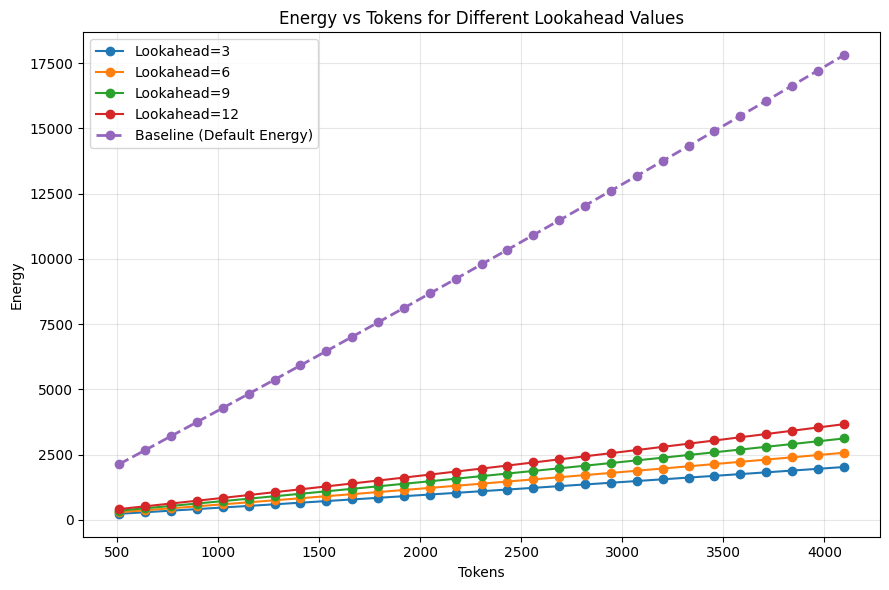

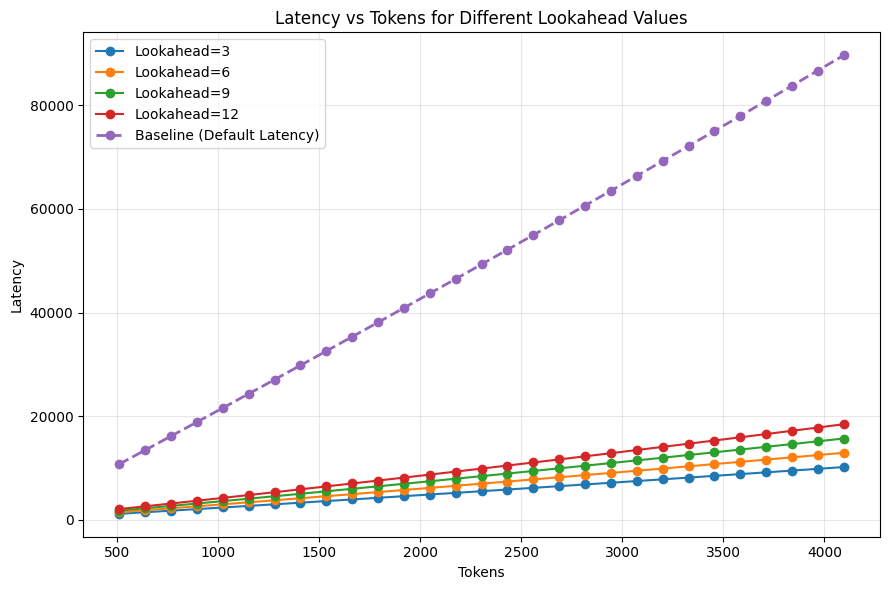

In [123]:
results_data

import matplotlib.pyplot as plt
from collections import defaultdict

# ---- Parse results_data robustly ----
# Supports either:
# 1) ['Tokens','Lookahead','Energy','Latency','Default Energy','Default Latency', [512,...], [640,...], ...]
# 2) [['Tokens',...], [512,...], [640,...], ...]

def parse_results_data(results_data):
    if not results_data:
        raise ValueError("results_data is empty")

    # Case 1: flat mixed list
    if isinstance(results_data[0], str):
        headers = results_data[:6]
        rows = [x for x in results_data[6:] if isinstance(x, (list, tuple)) and len(x) >= 6]
    # Case 2: first element is header row
    elif isinstance(results_data[0], (list, tuple)) and len(results_data[0]) >= 6:
        headers = list(results_data[0])
        rows = [x for x in results_data[1:] if isinstance(x, (list, tuple)) and len(x) >= 6]
    else:
        raise ValueError("Unrecognized results_data format")

    return headers, rows

headers, rows = parse_results_data(results_data)

# Column order expected from your screenshot:
# [Tokens, Lookahead, Energy, Latency, Default Energy, Default Latency]
TOKENS_IDX = 0
LOOKAHEAD_IDX = 1
ENERGY_IDX = 2
LATENCY_IDX = 3
DEFAULT_ENERGY_IDX = 4
DEFAULT_LATENCY_IDX = 5

# ---- Organize data ----
energy_by_lookahead = defaultdict(list)
latency_by_lookahead = defaultdict(list)

baseline_energy = {}
baseline_latency = {}

for row in rows:
    tokens = row[TOKENS_IDX]
    lookahead = row[LOOKAHEAD_IDX]
    energy = row[ENERGY_IDX]
    latency = row[LATENCY_IDX]
    default_energy = row[DEFAULT_ENERGY_IDX]
    default_latency = row[DEFAULT_LATENCY_IDX]

    energy_by_lookahead[lookahead].append((tokens, energy))
    latency_by_lookahead[lookahead].append((tokens, latency))

    # Store one baseline value per token count
    # If repeated across lookaheads, this will overwrite with the same value
    baseline_energy[tokens] = default_energy
    baseline_latency[tokens] = default_latency

# Sort everything by token count
for lookahead in energy_by_lookahead:
    energy_by_lookahead[lookahead].sort(key=lambda x: x[0])

for lookahead in latency_by_lookahead:
    latency_by_lookahead[lookahead].sort(key=lambda x: x[0])

baseline_tokens = sorted(baseline_energy.keys())
baseline_energy_y = [baseline_energy[t] for t in baseline_tokens]
baseline_latency_y = [baseline_latency[t] for t in baseline_tokens]

# ---- Plot 1: Energy ----
plt.figure(figsize=(9, 6))

for lookahead in sorted(energy_by_lookahead.keys()):
    xs = [t for t, _ in energy_by_lookahead[lookahead]]
    ys = [e for _, e in energy_by_lookahead[lookahead]]
    plt.plot(xs, ys, marker='o', label=f'Lookahead={lookahead}')

plt.plot(
    baseline_tokens,
    baseline_energy_y,
    marker='o',
    linestyle='--',
    linewidth=2,
    label='Baseline (Default Energy)'
)

plt.xlabel('Tokens')
plt.ylabel('Energy')
plt.title('Energy vs Tokens for Different Lookahead Values')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ---- Plot 2: Latency ----
plt.figure(figsize=(9, 6))

for lookahead in sorted(latency_by_lookahead.keys()):
    xs = [t for t, _ in latency_by_lookahead[lookahead]]
    ys = [l for _, l in latency_by_lookahead[lookahead]]
    plt.plot(xs, ys, marker='o', label=f'Lookahead={lookahead}')

plt.plot(
    baseline_tokens,
    baseline_latency_y,
    marker='o',
    linestyle='--',
    linewidth=2,
    label='Baseline (Default Latency)'
)

plt.xlabel('Tokens')
plt.ylabel('Latency')
plt.title('Latency vs Tokens for Different Lookahead Values')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

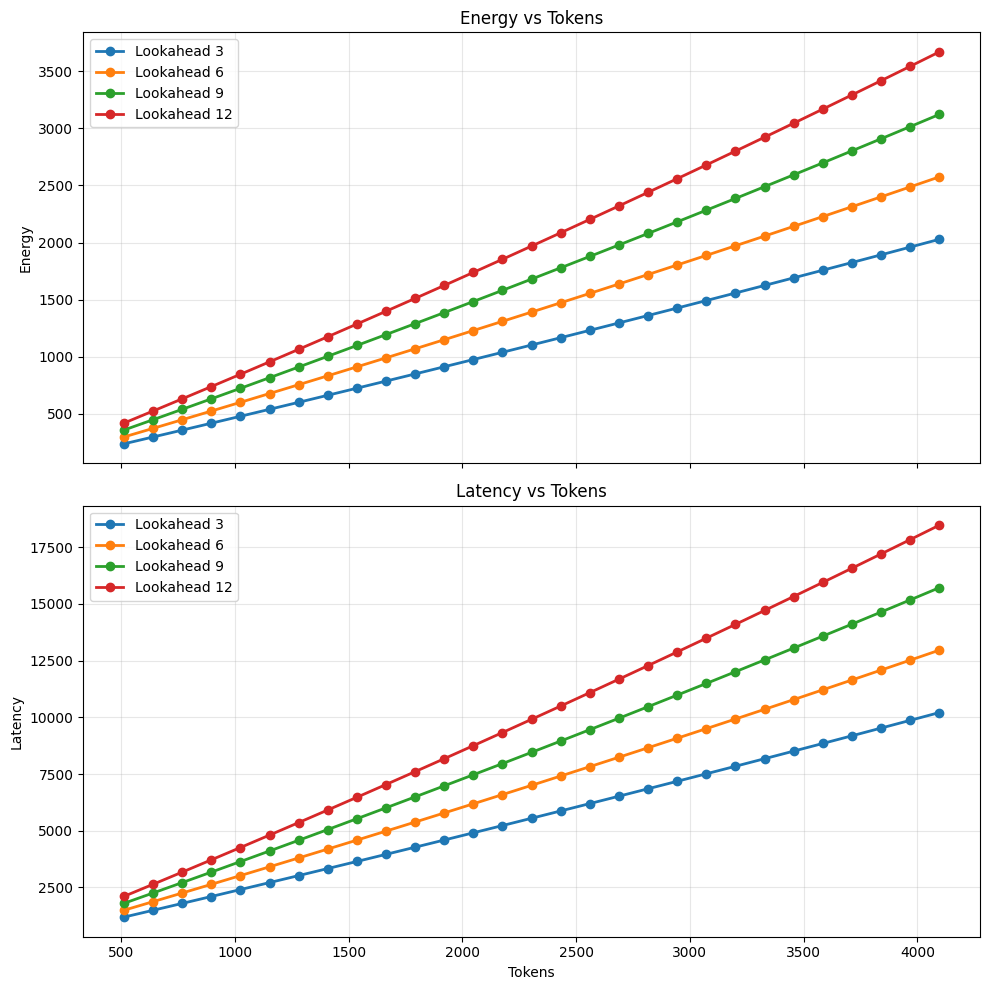

In [119]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv(
    "milestone_1_results.csv",
    skiprows=4,
    header=None,
    names=["tokens", "lookahead", "energy", "latency"],
)

for col in ["tokens", "lookahead", "energy", "latency"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

lookaheads = sorted(df["lookahead"].unique())

fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

for la in lookaheads:
    sub = df[df["lookahead"] == la]

    axes[0].plot(
        sub["tokens"],
        sub["energy"],
        marker="o",
        linewidth=2,
        label=f"Lookahead {int(la)}",
    )

    axes[1].plot(
        sub["tokens"],
        sub["latency"],
        marker="o",
        linewidth=2,
        label=f"Lookahead {int(la)}",
    )

axes[0].set_title("Energy vs Tokens")
axes[0].set_ylabel("Energy")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_title("Latency vs Tokens")
axes[1].set_xlabel("Tokens")
axes[1].set_ylabel("Latency")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

In [12]:
p_8192_6 = evaluate_workload(8192, 6) 

Currently on 0


/home/build/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:296: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


Currently on 1


/home/build/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:296: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


Currently on 2


...

/home/build/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:296: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


Currently on 5


/home/build/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:296: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


on Validator


/home/build/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:296: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


In [13]:

p_8192_9 = evaluate_workload(8192, 8) 

Currently on 0


/home/build/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:296: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


Currently on 1


/home/build/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:296: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


Currently on 2


...

/home/build/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:296: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


Currently on 7


/home/build/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:296: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


on Validator


/home/build/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:296: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


In [14]:
kv_8192_6 = default_kv_cached(8192, 6) 

Iteration 0


/home/build/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:296: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


Iteration 1


/home/build/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:296: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


Iteration 2


...

/home/build/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:296: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


Iteration 4


/home/build/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:296: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


Iteration 5


/home/build/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:296: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


In [15]:
kv_8192_8 = default_kv_cached(8192, 8) 

Iteration 0


/home/build/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:296: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


Iteration 1


/home/build/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:296: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


Iteration 2


...

/home/build/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:296: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


Iteration 6


/home/build/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:296: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


Iteration 7


/home/build/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:296: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


In [16]:
p_8192_6

(5619.722588845864, 28278.09765625)

In [18]:
p_8192_9

(6453.370788773605, 32470.90087890625)

In [19]:
kv_8192_6

(18727.8918140763, 94275.787109375)

In [20]:
kv_8192_8

(24973.876055258792, 125717.923828125)

TypeError: unsupported operand type(s) for /: 'tuple' and 'tuple'